# **Configurations**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/College/FLEX-Med/backend/federated_learning

# Dependency Installation
!pip install fastapi uvicorn pyngrok nest-asyncio flwr["simulation"] flwr_datasets datasets supabase -q

PROJECT_ROOT = "/content/drive/MyDrive/College/FLEX-Med/backend/federated_learning"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/College/FLEX-Med/backend/federated_learning


# **Verify if the environment is setup for FL simulation**

In [ ]:
#!/usr/bin/env python3
"""
FL Health Verification Script v3.0 (Jupyter / Colab Safe)

Updated for v3.0 architecture:
- Checks 3-folder dataset structure (anchor, test, local_train)
- Validates Dirichlet partitioning configuration
- Verifies num-supernodes matches client count in data.json
- No longer checks deprecated per-client dataset folders
"""

import os
import json
import re
import sys
from pathlib import Path
from typing import Dict, List, Tuple

# =====================================================
# PROJECT ROOT RESOLUTION (JUPYTER SAFE)
# =====================================================
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# =====================================================
# ANSI COLORS
# =====================================================
class Colors:
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    BLUE = '\033[94m'
    BOLD = '\033[1m'
    END = '\033[0m'


def print_header(text: str):
    print(f"\n{Colors.BOLD}{Colors.BLUE}{'=' * 70}{Colors.END}")
    print(f"{Colors.BOLD}{Colors.BLUE}{text.center(70)}{Colors.END}")
    print(f"{Colors.BOLD}{Colors.BLUE}{'=' * 70}{Colors.END}\n")


def print_success(text: str):
    print(f"{Colors.GREEN}  {text}{Colors.END}")


def print_warning(text: str):
    print(f"{Colors.YELLOW}  {text}{Colors.END}")


def print_error(text: str):
    print(f"{Colors.RED}  {text}{Colors.END}")


def print_info(text: str):
    print(f"  {text}")


# =====================================================
# DATASET CHECK (v3.0: 3-folder structure)
# =====================================================
def check_dataset_structure(
    dataset_path: Path,
    expected_classes: List[str] = ["all", "hem"]
) -> Tuple[bool, Dict]:
    stats = {}

    if not dataset_path.exists():
        return False, {"error": f"Path does not exist: {dataset_path}"}

    for class_name in expected_classes:
        class_path = dataset_path / class_name
        if not class_path.exists():
            return False, {"error": f"Missing class directory: {class_name}"}

        image_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
        images = [f for f in class_path.iterdir() if f.suffix.lower() in image_exts]
        stats[class_name] = len(images)

    total = sum(stats.values())
    if total == 0:
        return False, {"error": "No images found in dataset"}

    for cls in expected_classes:
        stats[f"{cls}_pct"] = stats[cls] / total * 100

    stats["total"] = total
    return True, stats


def verify_datasets(use_colab: bool = True) -> bool:
    print_header("Step 1: Dataset Structure (v3.0 - Dirichlet Partitioning)")

    if use_colab:
        base_path = Path("/content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc")
    else:
        base_path = PROJECT_ROOT.parent / "datasets" / "cnmc"

    # v3.0 requires exactly 3 folders (no per-client datasets)
    datasets = {
        "Public Anchor (20%)": base_path / "cnmc_public_anchor",
        "Public Test (10%)":   base_path / "cnmc_public_test",
        "Local Train (70%)":   base_path / "cnmc_local_train",
    }

    all_valid = True

    for name, path in datasets.items():
        valid, stats = check_dataset_structure(path)
        if valid:
            print_success(f"{name}: {path}")
            print_info(f"  Total: {stats['total']} images")
            print_info(f"  Leukemia (all): {stats['all']:,} ({stats['all_pct']:.1f}%)")
            print_info(f"  Healthy  (hem): {stats['hem']:,} ({stats['hem_pct']:.1f}%)")
        else:
            print_error(f"{name}: MISSING")
            print_info(f"  {stats.get('error')}")
            all_valid = False

    if all_valid:
        print_info("")
        print_success("All 3 dataset folders present (v3.0 Dirichlet partitioning ready)")
    else:
        print_info("")
        print_error("Missing dataset folders. Required structure:")
        print_info(f"  {base_path}/")
        print_info(f"    cnmc_public_anchor/  (20% balanced anchor data)")
        print_info(f"    cnmc_public_test/    (10% balanced test data)")
        print_info(f"    cnmc_local_train/    (70% shared training data)")

    return all_valid


# =====================================================
# CLIENT CONFIG CHECK
# =====================================================
def verify_client_config() -> bool:
    print_header("Step 2: Client Configuration (client_data.json)")

    config_path = PROJECT_ROOT / "flex_med" / "utils" / "client_data.json"

    if not config_path.exists():
        print_warning(f"Config file not found: {config_path}")
        print_info("  This is normal before the first FL run.")
        print_info("  The file is auto-generated when /start_fl is called.")
        return True  # Not a failure, just not yet created

    if config_path.stat().st_size == 0:
        print_error(f"Config file is empty (0 bytes): {config_path}")
        print_info("  Action: Re-trigger FL from the frontend.")
        return False

    try:
        with open(config_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError as e:
        print_error(f"Corrupted JSON in {config_path}")
        print_info(f"  Error: {e}")
        return False

    # Handle both wrapped {"clients": [...]} and flat [...] formats
    clients = data.get('clients', data) if isinstance(data, dict) else data

    if not clients:
        print_error("No clients found in config.")
        return False

    sim_id = data.get('simulation_id', 'N/A') if isinstance(data, dict) else 'N/A'
    print_success(f"Loaded config: {config_path}")
    print_info(f"  Simulation ID: {sim_id}")
    print_info(f"  Number of clients: {len(clients)}")

    valid_models = ['resnet50', 'mobilenet_v2', 'densenet121', 'efficientnet_b0']

    for client in clients:
        c_id = client.get('id', '?')
        c_name = client.get('client_name', 'Unknown')
        c_model = client.get('model_type', 'Unknown')

        print_info(f"\n  Client {c_id}: {c_name}")
        print_info(f"    Model: {c_model}")

        if c_model not in valid_models:
            print_error(f"    Invalid model type! Must be one of: {valid_models}")
            return False

        model_path = Path(client.get('model_path', ''))
        if model_path.exists():
            print_warning(f"    Existing checkpoint: {model_path}")
        else:
            print_success(f"    Fresh training (no checkpoint)")

    return True


# =====================================================
# FL CONFIG & SUPERNODES CONSISTENCY CHECK
# =====================================================
def verify_fl_config() -> bool:
    print_header("Step 3: FL Configuration (pyproject.toml)")

    config_path = PROJECT_ROOT / "pyproject.toml"

    if not config_path.exists():
        print_error("pyproject.toml not found")
        return False

    content = config_path.read_text()
    params = {}

    for line in content.splitlines():
        line = line.strip()
        if '=' in line and not line.startswith('#') and not line.startswith('['):
            k, v = line.split('=', 1)
            params[k.strip()] = v.split('#')[0].strip().strip('"')

    print_success("FL config loaded")
    print_info(f"  Rounds:       {params.get('num-server-rounds', '?')}")
    print_info(f"  Local epochs: {params.get('local-epochs', '?')}")
    print_info(f"  Batch size:   {params.get('batch-size', '?')}")
    print_info(f"  LR:           {params.get('lr', '?')}")
    print_info(f"  LR decay:     {params.get('lr-decay', '?')}")
    print_info(f"  Distill LR:   {params.get('distill-lr', '?')}")
    print_info(f"  Distill epochs: {params.get('distill-epochs', '?')}")
    print_info(f"  Temperature:  {params.get('temperature', '?')}")

    # Check num-supernodes consistency with client_data.json
    supernodes_matches = re.findall(r'num-supernodes\s*=\s*(\d+)', content)
    if supernodes_matches:
        supernodes_values = list(set(supernodes_matches))
        num_supernodes = int(supernodes_values[0])

        if len(supernodes_values) > 1:
            print_error(f"    Inconsistent num-supernodes values: {supernodes_matches}")
            print_info(f"    Both entries in pyproject.toml must match!")
            return False

        print_info(f"  num-supernodes: {num_supernodes}")

        # Cross-check with client_data.json
        client_config_path = PROJECT_ROOT / "flex_med" / "utils" / "client_data.json"
        if client_config_path.exists() and client_config_path.stat().st_size > 0:
            try:
                with open(client_config_path) as f:
                    data = json.load(f)
                clients = data.get('clients', data) if isinstance(data, dict) else data
                num_clients = len(clients)

                if num_supernodes == num_clients:
                    print_success(f"    num-supernodes ({num_supernodes}) matches client count ({num_clients})")
                else:
                    print_error(f"    MISMATCH: num-supernodes={num_supernodes} but client_data.json has {num_clients} clients!")
                    print_info(f"    This WILL cause 'Partition ID exceeds number of clients' errors.")
                    print_info(f"    Fix: Update pyproject.toml or re-trigger /start_fl.")
                    return False
            except (json.JSONDecodeError, Exception):
                pass
    else:
        print_warning("  num-supernodes not found in pyproject.toml")

    return True


# =====================================================
# DIRICHLET CONFIG CHECK
# =====================================================
def verify_dirichlet_config() -> bool:
    print_header("Step 4: Dirichlet Partitioning Configuration")

    alpha = os.getenv("FLEX_MED_DIRICHLET_ALPHA", "not set (default: 0.5)")
    seed = os.getenv("FLEX_MED_DIRICHLET_SEED", "not set (default: 42)")
    min_size = os.getenv("FLEX_MED_DIRICHLET_MIN_PARTITION_SIZE", "not set (default: 100)")
    train_path = os.getenv("LOCAL_TRAIN_DATASET_PATH", "not set (uses default)")

    print_info(f"  FLEX_MED_DIRICHLET_ALPHA:              {alpha}")
    print_info(f"  FLEX_MED_DIRICHLET_SEED:               {seed}")
    print_info(f"  FLEX_MED_DIRICHLET_MIN_PARTITION_SIZE:  {min_size}")
    print_info(f"  LOCAL_TRAIN_DATASET_PATH:               {train_path}")

    print_info("")
    print_info("  Alpha guide:")
    print_info("    0.1  = Extreme heterogeneity (very skewed)")
    print_info("    0.5  = Moderate heterogeneity (default)")
    print_info("    1.0  = Mild heterogeneity")
    print_info("    10.0 = Nearly IID (uniform)")

    print_success("Dirichlet config OK (runtime partitioning)")
    return True


# =====================================================
# CLEAN STATE CHECK
# =====================================================
def verify_clean_state(use_colab: bool = True) -> bool:
    print_header("Step 5: Model Checkpoints & Clean State")

    models_dir = (
        Path("/content/drive/MyDrive/College/FLEX-Med/backend/models")
        if use_colab
        else PROJECT_ROOT.parent / "models"
    )

    if not models_dir.exists():
        print_success("No models directory (fresh start)")
        return True

    checkpoints = list(models_dir.glob("*.pt"))
    if checkpoints:
        print_warning(f"Found {len(checkpoints)} existing checkpoint(s):")
        for cp in checkpoints:
            size_mb = cp.stat().st_size / (1024 * 1024)
            print_info(f"    {cp.name} ({size_mb:.1f} MB)")
        print_info("  These will be resumed from if model_path matches.")
    else:
        print_success("No checkpoints found (clean start)")

    # Check for stale checkpoint directory
    checkpoints_dir = (
        Path("/content/drive/MyDrive/College/FLEX-Med/backend/checkpoints")
        if use_colab
        else PROJECT_ROOT.parent / "checkpoints"
    )
    if checkpoints_dir.exists():
        ckpt_files = list(checkpoints_dir.glob("*"))
        if ckpt_files:
            print_warning(f"Found checkpoint directory with {len(ckpt_files)} file(s)")
            print_info(f"    Path: {checkpoints_dir}")

    return True


# =====================================================
# MAIN
# =====================================================
def main():
    print(f"\n{Colors.BOLD}FLEX-Med FL Health Verification (v3.0){Colors.END}")
    print(f"{Colors.BOLD}Dirichlet Partitioning | Runtime Data Heterogeneity{Colors.END}")

    results = {
        "Datasets":    verify_datasets(use_colab=True),
        "Client Config": verify_client_config(),
        "FL Config":   verify_fl_config(),
        "Dirichlet":   verify_dirichlet_config(),
        "Clean State": verify_clean_state(use_colab=True),
    }

    print_header("Verification Summary")

    all_passed = True
    for name, passed in results.items():
        if passed:
            print_success(f"{name}")
        else:
            print_error(f"{name}")
            all_passed = False

    print("")
    if all_passed:
        print_success("All checks passed - Ready for FL simulation")
    else:
        print_error("Some checks failed - Fix issues before training")

main()

# **API Definition**

In [ ]:
import os
import sys
import json
import logging
import subprocess
from typing import List, Tuple
import re
from datetime import datetime

from fastapi import FastAPI, BackgroundTasks, HTTPException
from pydantic import BaseModel
from starlette.middleware.cors import CORSMiddleware

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================

# Import configuration from config.py
try:
    from flex_med.utils.config import (
        PROJECT_DIR,
        SIMULATION_LOG_PATH,
        CLIENT_INFO_FILE_PATH,
        PYPROJECT_PATH,
        RUN_SIMULATION_SHELL_FILE_PATH,
    )
except ImportError:
    import sys
    sys.path.append(os.getcwd())
    from flex_med.utils.config import (
        PROJECT_DIR,
        SIMULATION_LOG_PATH,
        CLIENT_INFO_FILE_PATH,
        PYPROJECT_PATH,
        RUN_SIMULATION_SHELL_FILE_PATH,
    )

os.makedirs(PROJECT_DIR, exist_ok=True)

# ==========================================
# 2. SERVER LOGGING SETUP
# ==========================================

logger = logging.getLogger("inference_logger")
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

stream_handler = logging.StreamHandler(sys.stdout)

formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

logger.info("=== Flex-Med Orchestrator Started ===")

# ==========================================
# 3. CONFIGURATION VALIDATION
# ==========================================

def validate_client_config(client) -> Tuple[bool, str]:
    """
    Validate client configuration

    Returns:
        (is_valid, error_message)
    """
    valid_models = [
        'resnet50',         # The Industry Standard
        'mobilenet_v2',     # Mobile Optimized
        'densenet121',      # High Dense Connections
        'efficientnet_b0',  # Modern Efficiency Optimizer
    ]
    if client.model_type not in valid_models:
        return False, f"Invalid model type: {client.model_type}. Must be one of {valid_models}"

    if not client.model_path:
        return False, f"Client {client.client_name} has no model_path"

    model_dir = os.path.dirname(client.model_path)
    if not os.path.exists(model_dir):
        try:
            os.makedirs(model_dir, exist_ok=True)
            logger.info(f"Created model directory: {model_dir}")
        except Exception as e:
            return False, f"Cannot create model directory: {model_dir}, error: {e}"

    return True, ""

# ==========================================
# 4. CREATE RUN SCRIPT
# ==========================================

def create_run_script(simulation_id: int, num_clients: int, supabase_url: str, supabase_key: str):
    """
    Creates the shell script that runs the Flower simulation.

    Includes a pre-flight check that verifies num-supernodes in pyproject.toml
    matches the number of clients in client_data.json, and fixes it if needed.
    This guards against Google Drive FUSE sync delays causing stale reads.

    Args:
        simulation_id: ID of the simulation in fl_simulations table
        num_clients: Expected number of FL clients (for verification)
        supabase_url: Supabase project URL
        supabase_key: Supabase API key
    """
    script_content = f"""#!/bin/bash
cd "{PROJECT_DIR}"

echo "[Script] Starting Flex-Med Simulation at $(date)..."
echo "[Script] Simulation ID: {simulation_id}"

# Export environment variables for FL system
export FLEX_MED_SIMULATION_ID="{simulation_id}"
export SUPABASE_URL="{supabase_url}"
export SUPABASE_KEY="{supabase_key}"

# Optional: Configure Ray memory settings
export RAY_memory_usage_threshold="0.98"

# Only install the local package in editable mode (Fast & Lightweight)
pip install -e . -q

# ==========================================
# PRE-FLIGHT: Verify num-supernodes matches client count
# Guards against Google Drive FUSE sync delays
# ==========================================
sync  # Force filesystem flush

EXPECTED_CLIENTS={num_clients}
ACTUAL_SUPERNODES=$(grep -oP 'num-supernodes\\s*=\\s*\\K\\d+' pyproject.toml | head -1)
DATA_JSON_CLIENTS=$(python3 -c "
import json
d = json.load(open('{CLIENT_INFO_FILE_PATH}'))
clients = d.get('clients', d) if isinstance(d, dict) else d
print(len(clients))
")

echo "[Pre-flight] Expected clients:       $EXPECTED_CLIENTS"
echo "[Pre-flight] pyproject num-supernodes: $ACTUAL_SUPERNODES"
echo "[Pre-flight] client_data.json clients: $DATA_JSON_CLIENTS"

if [ "$ACTUAL_SUPERNODES" != "$EXPECTED_CLIENTS" ]; then
    echo "[Pre-flight] MISMATCH detected! Fixing pyproject.toml..."
    sed -i "s/num-supernodes = [0-9]*/num-supernodes = $EXPECTED_CLIENTS/g" pyproject.toml
    sync
    NEW_VALUE=$(grep -oP 'num-supernodes\\s*=\\s*\\K\\d+' pyproject.toml | head -1)
    echo "[Pre-flight] Fixed: num-supernodes = $NEW_VALUE"
fi

if [ "$DATA_JSON_CLIENTS" != "$EXPECTED_CLIENTS" ]; then
    echo "[Pre-flight] ERROR: client_data.json has $DATA_JSON_CLIENTS clients but expected $EXPECTED_CLIENTS"
    echo "[Pre-flight] Aborting simulation."
    exit 1
fi

echo "[Pre-flight] All checks passed. Starting FL..."

# Run Flower CLI
flwr run .
"""

    with open(RUN_SIMULATION_SHELL_FILE_PATH, "w") as f:
        f.write(script_content)

    os.chmod(RUN_SIMULATION_SHELL_FILE_PATH, 0o755)
    logger.info(f"Created run_simulation.sh at {RUN_SIMULATION_SHELL_FILE_PATH}")

    return RUN_SIMULATION_SHELL_FILE_PATH

# ==========================================
# 5. BACKGROUND TASK
# ==========================================

def run_simulation_task():
    """Runs the FL simulation in background."""
    logger.info("="*70)
    logger.info("Starting Flower Simulation in Background")
    logger.info("="*70)

    try:
        logger.info("\n[Background Task] Running Flower Simulation...")

        with open(SIMULATION_LOG_PATH, "w") as log_file:
            process = subprocess.run(
                ["bash", SCRIPT_PATH],
                stdout=log_file,
                stderr=log_file,
                text=True
            )

        return_code = process.returncode

        if return_code == 0:
            logger.info("\n" + "="*70)
            logger.info("Federated Learning Simulation COMPLETED Successfully")
            logger.info("="*70)

        else:
            logger.error("\n" + "="*70)
            logger.error(f"Federated Learning Simulation FAILED (return code: {return_code})")
            logger.error("="*70)

    except Exception as e:
        logger.error(f"\nSimulation error: {e}")
        import traceback
        logger.error(traceback.format_exc())

# ==========================================
# 6. PYDANTIC MODELS (v3.0 - Removed deprecated fields)
# ==========================================

class ClientConfig(BaseModel):
    """
    Client configuration schema for v3.0

    Removed fields (deprecated):
    - has_local_data (all clients now use Dirichlet partitioning)
    - dataset_path (replaced by shared LOCAL_TRAIN_DATASET_PATH)
    """
    id: int
    created_at: str
    client_name: str
    model_type: str
    status: str
    model_path: str
    metrics: str

class StartFLRequest(BaseModel):
    """
    New request format for FL simulation with database integration.

    Fields:
        simulation_id: ID of the simulation record in fl_simulations table
        clients: List of client configurations
        supabase_url: Supabase project URL for direct database access
        supabase_key: Supabase API key (anon key)
    """
    simulation_id: int
    clients: List[ClientConfig]
    supabase_url: str
    supabase_key: str

# ==========================================
# 7. FASTAPI APP
# ==========================================

app = FastAPI(title="Flex-Med Orchestrator")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ==========================================
# 8. ENDPOINTS
# ==========================================

@app.get("/")
def read_root():
    return {"message": "Flex-Med Orchestrator is running"}

def update_data_json(simulation_id: int, clients: List[ClientConfig], path: str = CLIENT_INFO_FILE_PATH):
    """
    Save client configuration to data.json with simulation metadata.

    Args:
        simulation_id: Simulation ID for tracking
        clients: List of client configurations
        path: Path to save the configuration file
    """
    try:
        client_dicts = [c.dict() for c in clients]

        # Wrap clients with simulation metadata (new format)
        config_data = {
            "simulation_id": simulation_id,
            "clients": client_dicts
        }

        os.makedirs(os.path.dirname(path), exist_ok=True)

        with open(path, "w") as f:
            json.dump(config_data, f, indent=2)

        logger.info(f"Updated data.json with simulation_id={simulation_id} and {len(clients)} clients")
        return True
    except Exception as e:
        logger.error(f"Failed to update data.json: {e}")
        return False

def update_pyproject_toml(num_clients: int, path: str = PYPROJECT_PATH):
    """Update pyproject.toml with correct num-supernodes."""
    try:
        if not os.path.exists(path):
            logger.error(f"pyproject.toml not found at {path}")
            return False

        with open(path, 'r') as f:
            content = f.read()

        pattern = r'(num-supernodes\s*=\s*)\d+'

        if not re.search(pattern, content):
            logger.warning("num-supernodes not found in pyproject.toml")
            return False

        old_match = re.search(r'num-supernodes\s*=\s*(\d+)', content)
        old_value = old_match.group(1) if old_match else "unknown"
        matches = re.findall(pattern, content)

        # Replace ALL occurrences (both local-simulation and app.federations sections)
        new_content = re.sub(pattern, f'\\g<1>{num_clients}', content)

        with open(path, 'w') as f:
            f.write(new_content)

        # Verify the write took effect by re-reading
        with open(path, 'r') as f:
            verify_content = f.read()

        verify_match = re.search(r'num-supernodes\s*=\s*(\d+)', verify_content)
        if verify_match and int(verify_match.group(1)) != num_clients:
            logger.error(f"Write verification failed! Expected {num_clients}, got {verify_match.group(1)}")
            return False

        logger.info(f"Updated pyproject.toml: num-supernodes {old_value} -> {num_clients} ({len(matches)} occurrences)")
        return True

    except Exception as e:
        logger.error(f"Failed to update pyproject.toml: {e}")
        return False

@app.post("/start_fl")
async def start_fl(
    request: StartFLRequest,
    background_tasks: BackgroundTasks,
):
    """
    Start federated learning simulation with v3.0 schema (no deprecated fields).

    This endpoint now receives:
    - simulation_id: ID of the simulation record in fl_simulations table
    - clients: List of client configurations (without has_local_data/dataset_path)
    - supabase_url: Supabase URL for direct database access
    - supabase_key: Supabase API key

    All clients now use runtime Dirichlet partitioning from shared LOCAL_TRAIN_DATASET_PATH.

    Steps:
    1. Validates client configurations
    2. Saves client config to data.json (with simulation_id wrapper)
    3. Updates pyproject.toml with correct num-supernodes (hard requirement)
    4. Creates run script with pre-flight verification
    5. Triggers the FL simulation in background
    """

    simulation_id = request.simulation_id
    clients = request.clients
    num_clients = len(clients)

    logger.info(f"=" * 70)
    logger.info(f"Received FL start request")
    logger.info(f"  - Simulation ID: {simulation_id}")
    logger.info(f"  - Number of clients: {num_clients}")
    logger.info(f"=" * 70)

    # Log client details
    for i, client in enumerate(clients):
        logger.info(f"  Client {i}: {client.client_name:20} | {client.model_type:15}")

    # ===== VALIDATION: CHECK CLIENT CONFIGS =====
    logger.info("\n[Endpoint] Validating client configurations...")

    validation_errors = []
    for i, client in enumerate(clients):
        is_valid, error_msg = validate_client_config(client)
        if not is_valid:
            validation_errors.append(f"Client {i}: {error_msg}")

    if validation_errors:
        error_detail = "\n".join(validation_errors)
        logger.error(f"Configuration validation failed:\n{error_detail}")
        raise HTTPException(
            status_code=400,
            detail=f"Invalid client configuration:\n{error_detail}"
        )

    logger.info("All client configurations validated")

    # ===== STEP 1: UPDATE DATA.JSON (with simulation_id) =====
    logger.info("\n[Endpoint] Step 1: Updating data.json...")

    if not update_data_json(simulation_id, clients, CLIENT_INFO_FILE_PATH):
        raise HTTPException(
            status_code=500,
            detail="Failed to save client configuration to data.json"
        )

    # ===== STEP 2: UPDATE PYPROJECT.TOML (hard requirement) =====
    logger.info("\n[Endpoint] Step 2: Updating pyproject.toml...")

    if not update_pyproject_toml(num_clients, PYPROJECT_PATH):
        raise HTTPException(
            status_code=500,
            detail=f"Failed to update pyproject.toml num-supernodes to {num_clients}. "
                   f"This would cause partition ID mismatch errors during FL."
        )

    # ===== STEP 3: CREATE RUN SCRIPT (with pre-flight verification) =====
    logger.info("\n[Endpoint] Step 3: Creating run script...")
    logger.info(f"  - FLEX_MED_SIMULATION_ID={simulation_id}")
    logger.info(f"  - SUPABASE_URL={request.supabase_url}")
    logger.info(f"  - SUPABASE_KEY=***hidden***")

    global SCRIPT_PATH
    SCRIPT_PATH = create_run_script(
        simulation_id=simulation_id,
        num_clients=num_clients,
        supabase_url=request.supabase_url,
        supabase_key=request.supabase_key
    )

    # ===== STEP 4: SET ENVIRONMENT VARIABLES =====
    os.environ['FLEX_MED_SIMULATION_ID'] = str(simulation_id)
    os.environ['SUPABASE_URL'] = request.supabase_url
    os.environ['SUPABASE_KEY'] = request.supabase_key

    client_config_json = json.dumps({
        "simulation_id": simulation_id,
        "clients": [c.dict() for c in clients]
    })
    os.environ['FLEX_MED_CLIENT_CONFIGS'] = client_config_json

    # ===== STEP 5: TRIGGER SIMULATION =====
    logger.info("\n[Endpoint] Step 4: Starting FL simulation...")
    logger.info(f"  - Number of clients: {num_clients}")
    logger.info(f"  - All clients use Dirichlet partitioning from shared LOCAL_TRAIN_DATASET_PATH")
    logger.info(f"  - Database: Metrics will be saved to client_simulation_metrics table")
    logger.info(f"  - Pre-flight checks will verify config before flwr run")
    logger.info(f"=" * 70 + "\n")

    # Trigger the background task
    background_tasks.add_task(run_simulation_task)

    return {
        "status": "accepted",
        "message": f"Federated simulation started with {num_clients} clients",
        "simulation_id": simulation_id,
        "num_clients": num_clients,
        "config_updated": {
            "data_json": CLIENT_INFO_FILE_PATH,
            "pyproject_toml": PYPROJECT_PATH
        },
        "log_path": SIMULATION_LOG_PATH,
        "database": {
            "metrics_table": "client_simulation_metrics",
            "simulation_table": "fl_simulations"
        },
        "version": "3.0"
    }

print("Flex-Med Orchestrator Ready (v3.0)")
print("  Endpoint: POST /start_fl")
print("  Schema: {simulation_id, clients, supabase_url, supabase_key}")
print("  All clients use Dirichlet partitioning from shared LOCAL_TRAIN_DATASET_PATH")
print("  Pre-flight checks verify num-supernodes before each FL run")

# **NGROK Setup**

In [6]:
import nest_asyncio
import uvicorn
import subprocess
import threading
from pyngrok import ngrok
from pyngrok.process import kill_process
from fastapi import FastAPI, BackgroundTasks, HTTPException
from starlette.middleware.cors import CORSMiddleware

# 0. Cleanup
try:
    ngrok.disconnect()
    kill_process()
except:
    pass

# 1. Auth & Tunnel
# REPLACE WITH YOUR ACTUAL TOKEN
AUTH_TOKEN = "38BI51ntfzceNwdU1BTYDLnAZib_3S3SmcwQJFykk89BGBmEJ"
ngrok.set_auth_token(AUTH_TOKEN)

http_tunnel = ngrok.connect(8000)
public_url = http_tunnel.public_url

print(f"🌐 API URL: {public_url}")
print(f"🚀 POST to start FL: {public_url}/start_fl")

# 2. Run Uvicorn
nest_asyncio.apply()

def run_uvicorn():
    uvicorn.run(app, port=8000, host="0.0.0.0")

thread = threading.Thread(target=run_uvicorn)
thread.start()

🌐 API URL: https://intraspinal-agape-deidra.ngrok-free.dev
🚀 POST to start FL: https://intraspinal-agape-deidra.ngrok-free.dev/start_fl


# **View Training Logs**

In [7]:
!tail -f "/content/drive/MyDrive/College/FLEX-Med/backend/federated_learning/flex_med/utils/simulation_run.log"

[Script] Starting Flex-Med Simulation at Mon Feb  9 05:09:36 PM UTC 2026...
[Script] Simulation ID: 1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 137.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 MB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.9.0+cu126 requires torch==2.9.0, but you have torch 2.7.1 which is inco

INFO:inference_logger:


2026-02-10 07:19:42,253 - INFO - ✅ Federated Learning Simulation COMPLETED Successfully


INFO:inference_logger:✅ Federated Learning Simulation COMPLETED Successfully


2026-02-10 07:19:42,254 - INFO - ======================================================================


INFO:inference_logger:======================================================================


^C


# **Kill process**

In [ ]:
# Kill any process running on port 8000
!fuser -k 8000/tcp

print("Attempted to kill processes on port 8000. Please re-run the FastAPI server cell now.")

# **Model Evaluation & Database Metrics Visualization**

🚀 FL ROUND-BY-ROUND METRICS VISUALIZATION

🔌 Connecting to Supabase...
✅ Connected

📊 Fetching metrics...
   Using simulation ID: 1
✅ Fetched 3 client record(s)

📊 FL TRAINING SUMMARY (ROUND-BY-ROUND PROGRESS)

Client 2 (Client ID: 2):
  Training Rounds: 10

  Round-by-Round Progress:
    Round 0 (Pre-FL):  Acc=0.00%, Loss=0.0000
    Round 1:           Acc=90.00%, Loss=0.4152
    Round 2:           Acc=87.31%, Loss=0.4035
    Round 3:           Acc=89.42%, Loss=0.3582
    Round 4:           Acc=88.08%, Loss=0.4116
    Round 5:           Acc=89.23%, Loss=0.3831
    Round 6:           Acc=89.62%, Loss=0.3873
    Round 7:           Acc=91.35%, Loss=0.3646
    Round 8:           Acc=90.77%, Loss=0.3509
    Round 9:           Acc=85.77%, Loss=0.4421
    Round 10:           Acc=89.04%, Loss=0.4147

  Overall Improvement:
    Pre-FL:  0.00%
    Final:   89.04%
    Change:  +89.04%

  Final Metrics (Round 10):
    Loss:      0.4147
    F1 Score:  78.16%
    Recall:    75.00%
    Precision: 81.

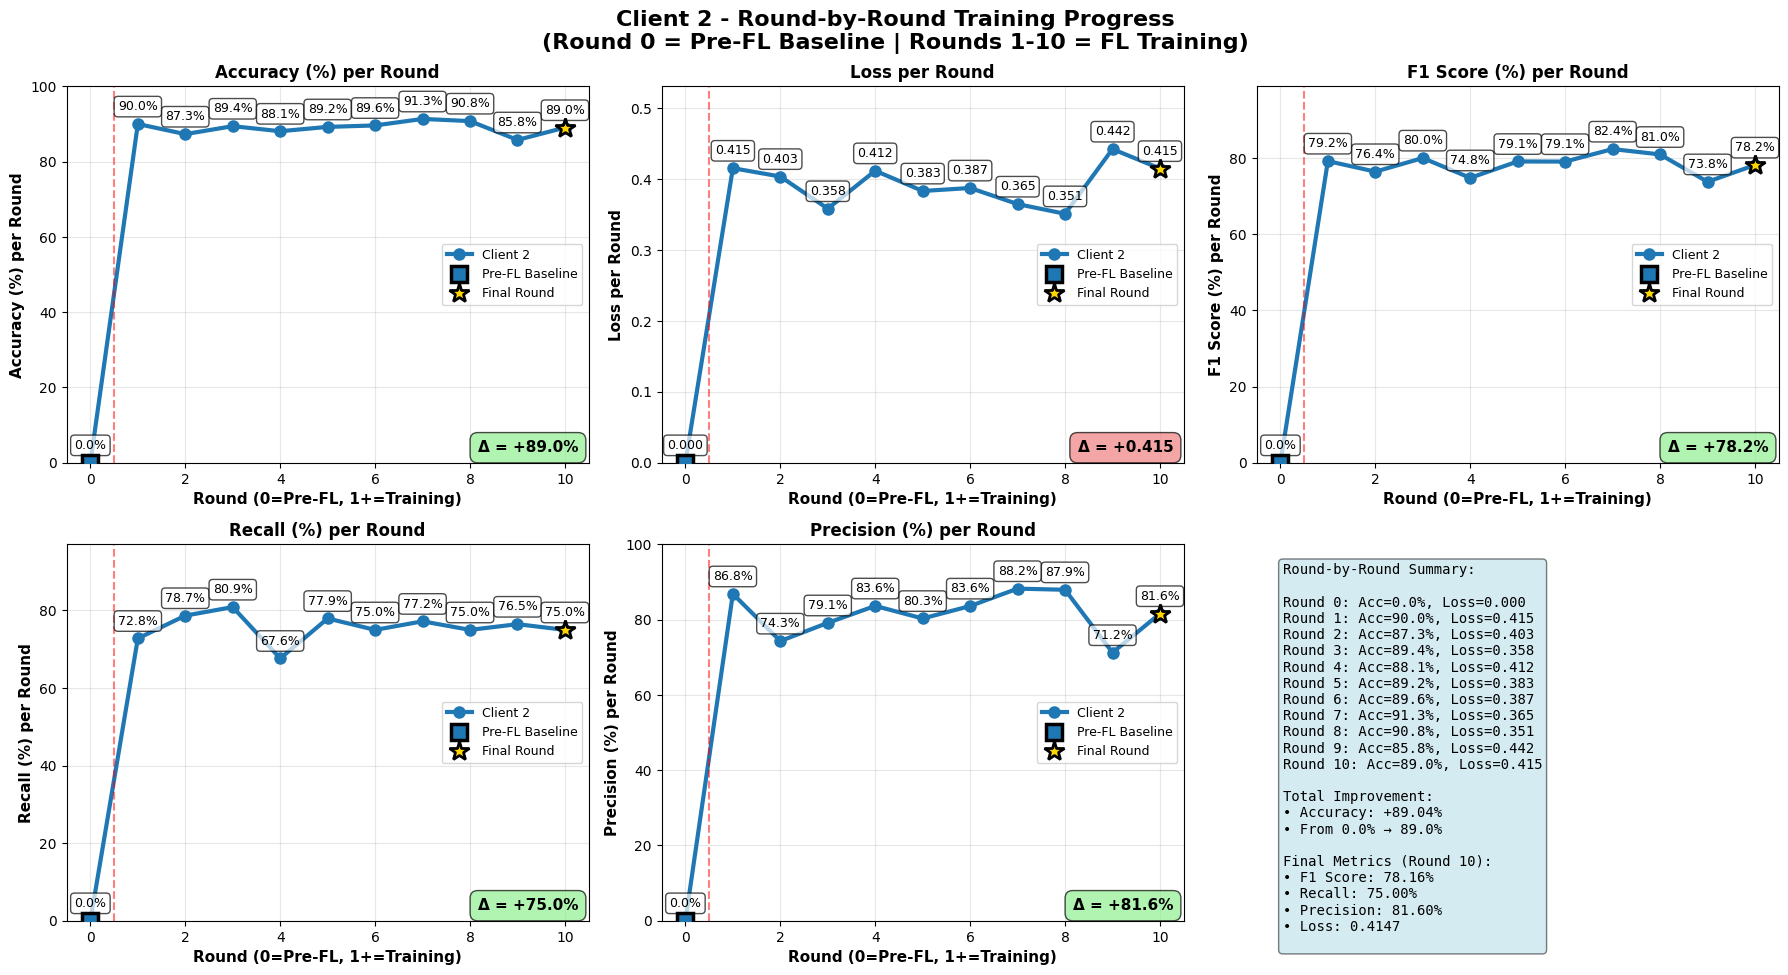

   Plotting Client 1 (10 training rounds)...


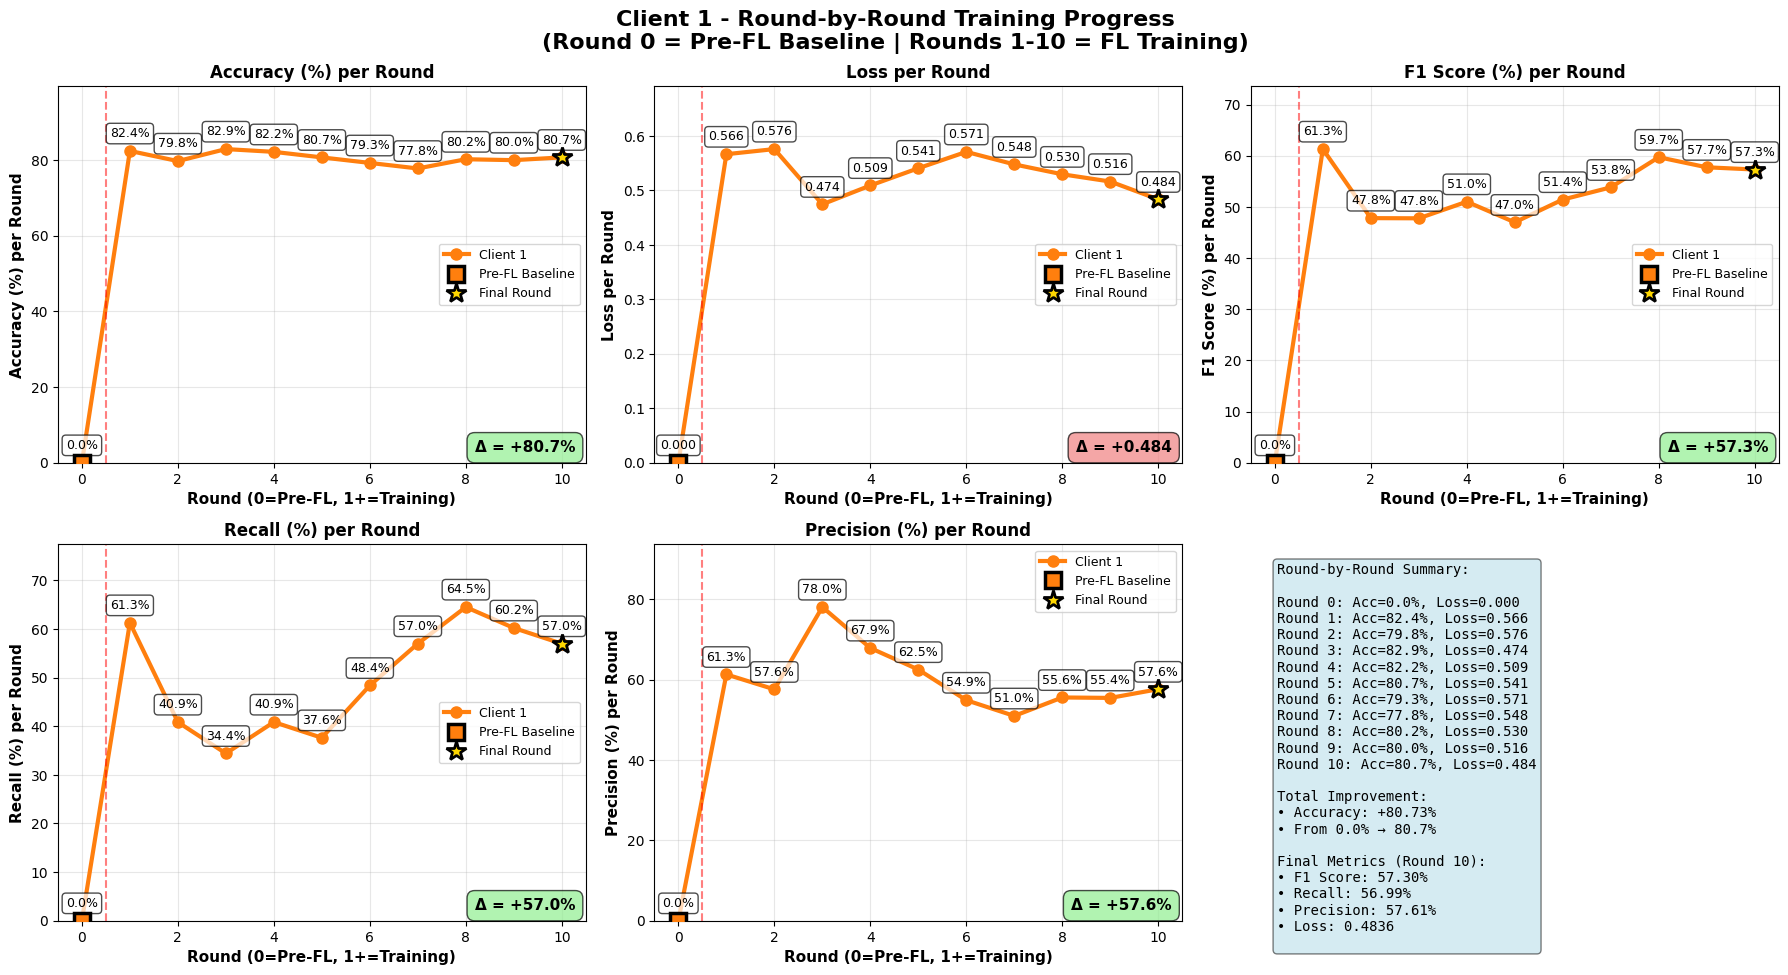

   Plotting Client 3 (10 training rounds)...


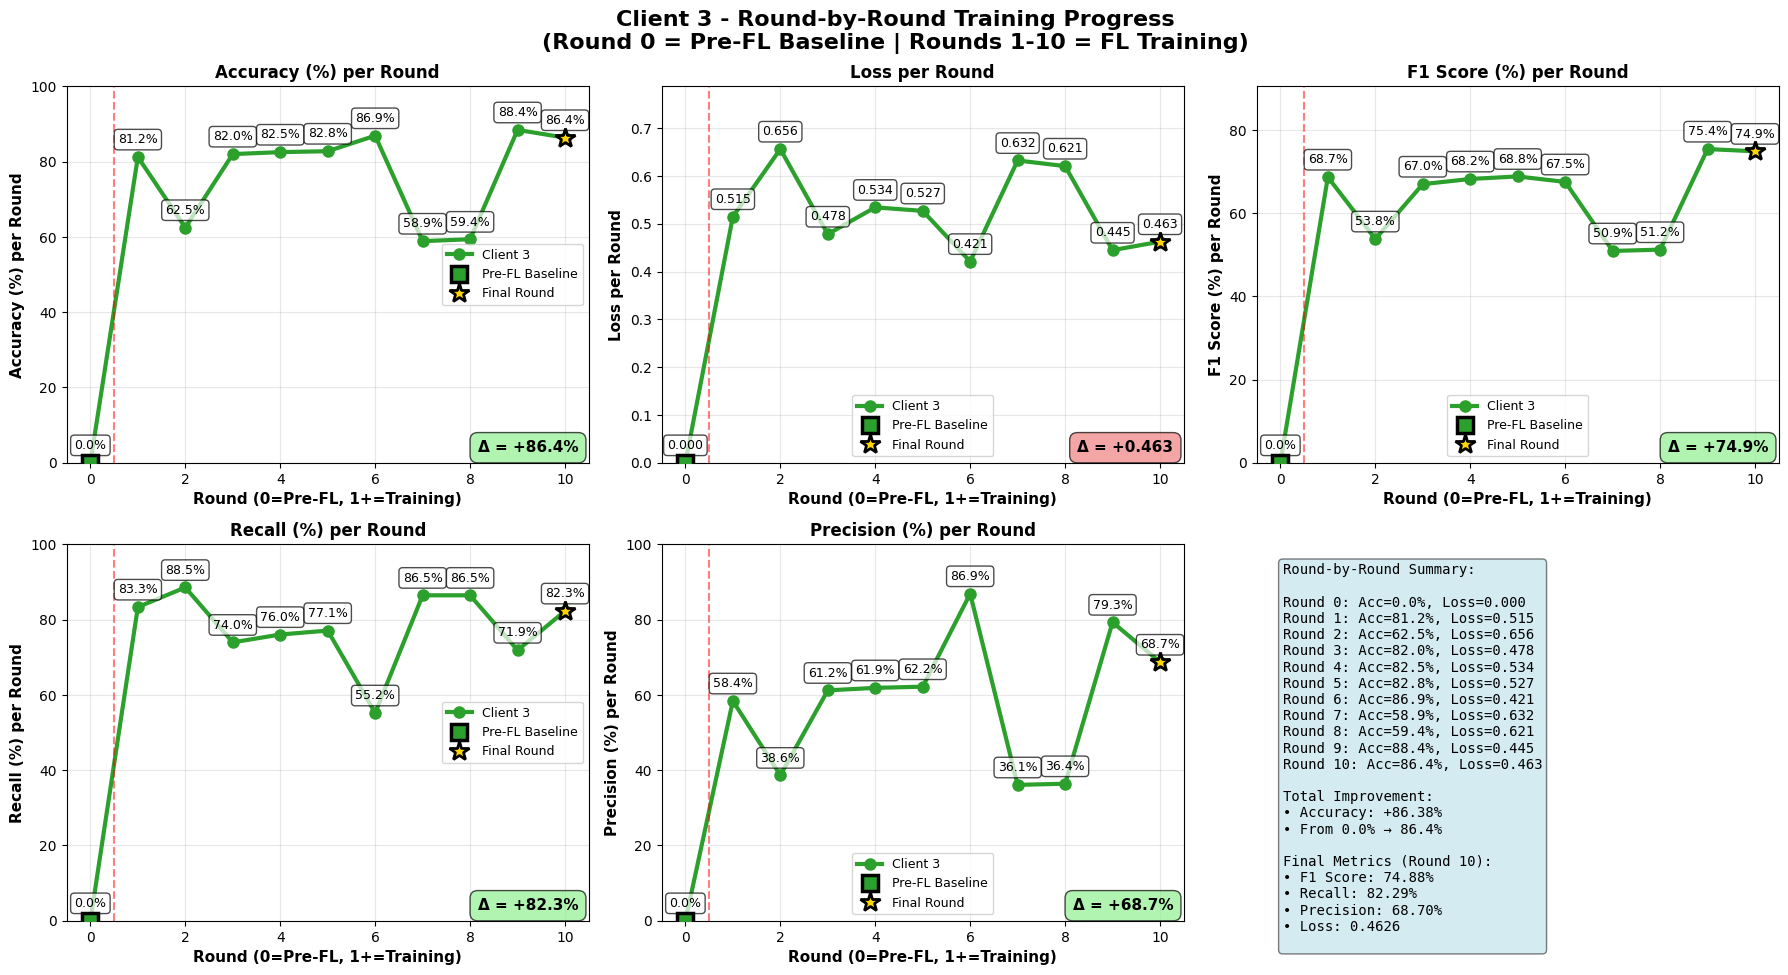


✅ Generated 3 individual client plot(s)

📊 Generating comparison plots...


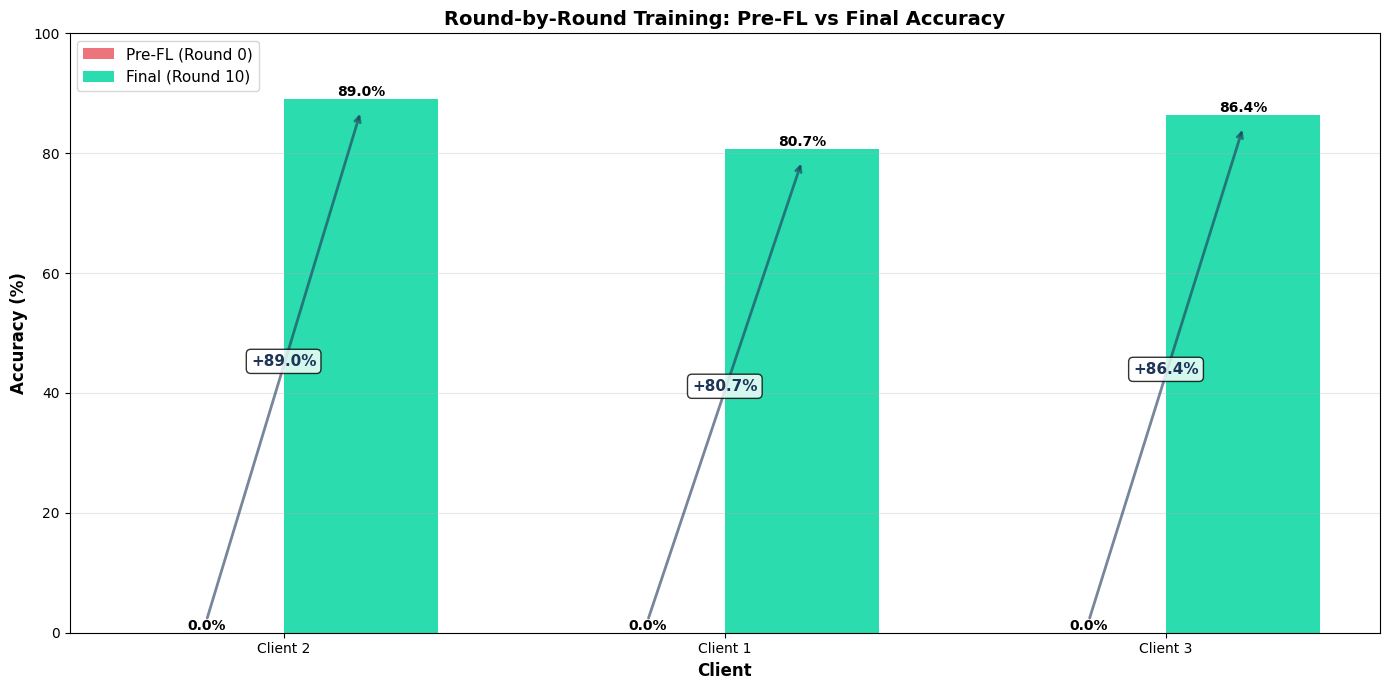

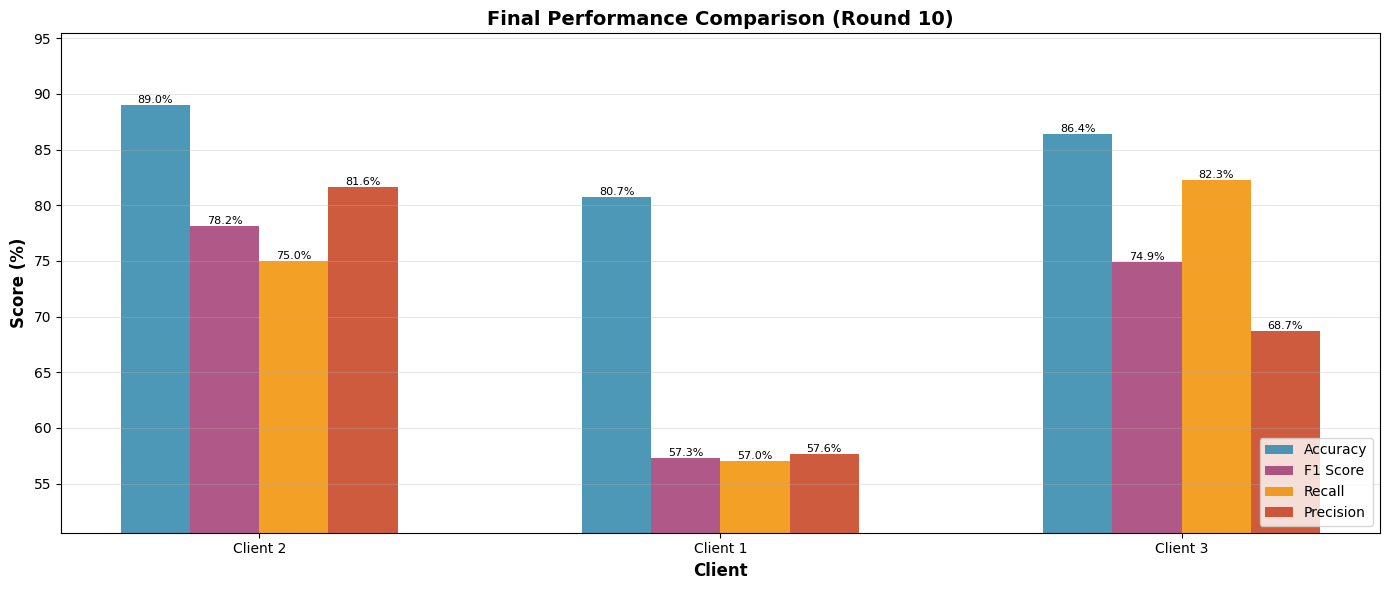

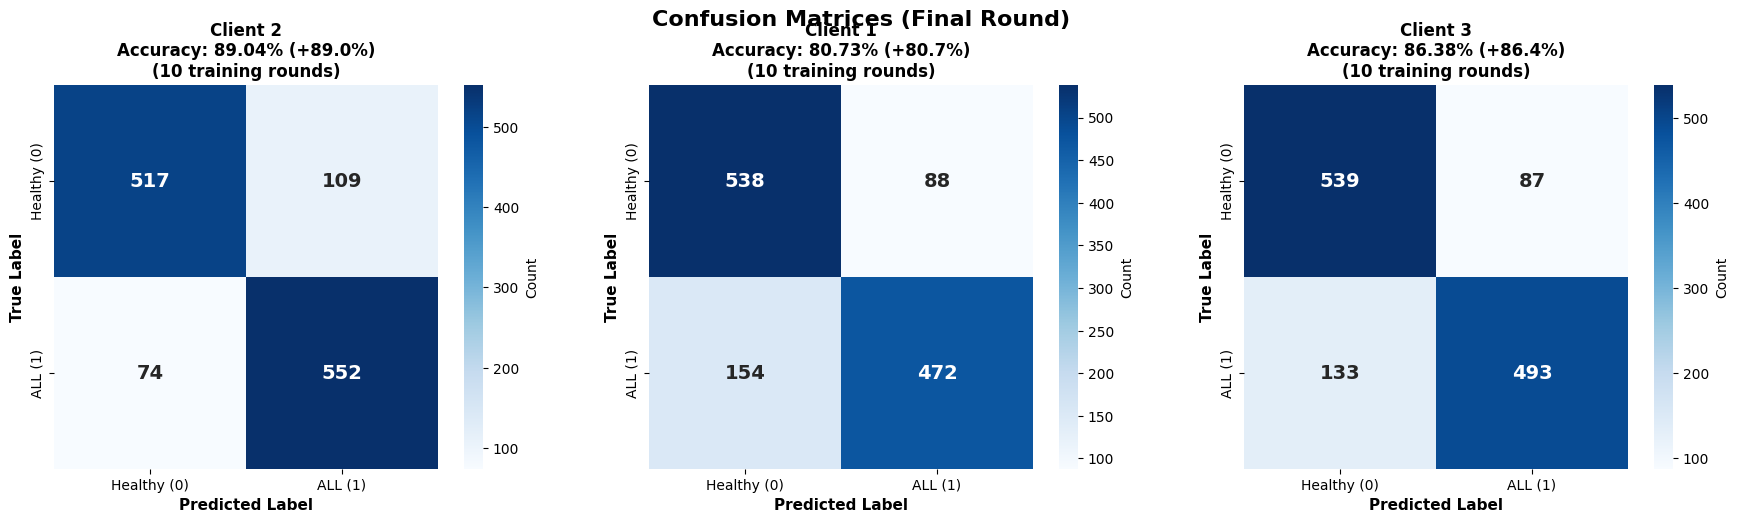


✅ All visualizations generated successfully!
📊 Visualized 10 training rounds per client


In [ ]:
# ==========================================
# FL METRICS VISUALIZATION (WITH PRE-FL BASELINE)
# ==========================================

import os
import sys
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from supabase import create_client, Client
from typing import Optional, Dict, List

# ==========================================
# CONFIGURATION
# ==========================================

MODEL_PATH = "/content/drive/MyDrive/College/FLEX-Med/backend/models/Delmon.pt"
SUPABASE_URL = os.getenv("SUPABASE_URL", "YOUR_SUPABASE_URL_HERE")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "YOUR_SUPABASE_ANON_KEY_HERE")
SIMULATION_ID: Optional[int] = None  # None = latest simulation
CLIENT_ID: Optional[int] = None  # None = all clients, or specific client ID (e.g., 1, 2)

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def connect_to_supabase() -> Client:
    """Initialize Supabase client."""
    if SUPABASE_URL == "YOUR_SUPABASE_URL_HERE":
        raise ValueError("⚠️ Please set SUPABASE_URL and SUPABASE_KEY")
    print(f"🔌 Connecting to Supabase...")
    supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
    print(f"✅ Connected\n")
    return supabase

def fetch_metrics(supabase: Client, simulation_id: Optional[int] = None, client_id: Optional[int] = None):
    """Fetch and parse metrics from database.

    This function extracts ROUND-BY-ROUND metrics to show training progress:
    - Round 0: Pre-FL baseline (before training)
    - Round 1+: Validation metrics after each FL round

    Args:
        supabase: Supabase client
        simulation_id: Simulation ID (None = latest)
        client_id: Client ID to filter by (None = all clients)
    """
    print(f"📊 Fetching metrics...")

    # Get latest simulation if not specified
    if simulation_id is None:
        response = supabase.table('fl_simulations').select('id').order('created_at', desc=True).limit(1).execute()
        if not response.data:
            raise ValueError("No simulations found")
        simulation_id = response.data[0]['id']
        print(f"   Using simulation ID: {simulation_id}")

    # Fetch metrics with optional client filter
    query = supabase.table('client_simulation_metrics') \
        .select('*') \
        .eq('simulation_id', simulation_id)

    if client_id is not None:
        query = query.eq('client_id', client_id)
        print(f"   Filtering by client_id: {client_id}")

    response = query.execute()

    if not response.data:
        if client_id is not None:
            raise ValueError(f"No metrics found for simulation_id={simulation_id}, client_id={client_id}")
        else:
            raise ValueError(f"No metrics found for simulation_id={simulation_id}")

    print(f"✅ Fetched {len(response.data)} client record(s)\n")

    # Parse into structured format
    clients_data = []
    for record in response.data:
        metrics = json.loads(record['metrics']) if isinstance(record['metrics'], str) else record['metrics']

        # ==========================================
        # EXTRACT ROUND-BY-ROUND METRICS
        # ==========================================

        # Round 0: PRE-FL baseline (before any training)
        pre_fl = metrics.get('global', {}).get('pre_fl', {})
        rounds = [{
            'round': 0,
            'accuracy': pre_fl.get('accuracy', 0) * 100,
            'loss': pre_fl.get('loss', 0),
            'f1_score': pre_fl.get('f1_score', 0) * 100,
            'recall': pre_fl.get('recall', 0) * 100,
            'precision': pre_fl.get('precision', 0) * 100,
        }]

        # Round 1+: Per-round validation metrics (ACTUAL TRAINING PROGRESS)
        for round_entry in metrics.get('rounds', []):
            val = round_entry.get('validation', {})
            rounds.append({
                'round': round_entry['round'],
                'accuracy': val.get('accuracy', 0) * 100,
                'loss': val.get('loss', 0),
                'f1_score': val.get('f1_score', 0) * 100,
                'recall': val.get('recall', 0) * 100,
                'precision': val.get('precision', 0) * 100,
            })

        # Use LAST ROUND metrics as final metrics (consistent with graphs)
        last_round = rounds[-1] if len(rounds) > 0 else rounds[0]

        # Extract confusion matrix from post-FL global evaluation
        post_fl = metrics.get('global', {}).get('post_fl', {})
        cm = post_fl.get('confusion_matrix', {})

        # Calculate improvement from Round 0 to Last Round
        pre_fl_accuracy = rounds[0]['accuracy']
        final_accuracy = last_round['accuracy']
        improvement = final_accuracy - pre_fl_accuracy

        clients_data.append({
            'client_id': record['client_id'],
            'client_name': record.get('client_name', f"Client {record['client_id']}"),
            'rounds': rounds,  # Full round-by-round progression
            'num_rounds': len(rounds) - 1,  # Excluding round 0
            'pre_fl_accuracy': pre_fl_accuracy,
            'final_accuracy': final_accuracy,  # From last round
            'final_loss': last_round['loss'],
            'final_f1': last_round['f1_score'],
            'final_recall': last_round['recall'],
            'final_precision': last_round['precision'],
            'improvement': improvement,
            'confusion_matrix': [[cm.get('TN', 0), cm.get('FP', 0)],
                                [cm.get('FN', 0), cm.get('TP', 0)]]
        })

    return clients_data

# ==========================================
# VISUALIZATION - INDIVIDUAL CLIENT GRAPHS
# ==========================================

def plot_individual_client_metrics(client_data: Dict, client_index: int = 0):
    """Plot all metrics for a single client showing ROUND-BY-ROUND progress.

    Args:
        client_data: Dictionary containing client metrics
        client_index: Index for color selection
    """

    color = plt.cm.tab10(client_index)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{client_data["client_name"]} - Round-by-Round Training Progress\n(Round 0 = Pre-FL Baseline | Rounds 1-{client_data["num_rounds"]} = FL Training)',
                 fontsize=16, fontweight='bold')

    metrics = ['accuracy', 'loss', 'f1_score', 'recall', 'precision']
    titles = ['Accuracy (%) per Round', 'Loss per Round', 'F1 Score (%) per Round',
              'Recall (%) per Round', 'Precision (%) per Round']
    positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]

    for metric, title, pos in zip(metrics, titles, positions):
        ax = axes[pos]

        rounds = [r['round'] for r in client_data['rounds']]
        values = [r[metric] for r in client_data['rounds']]

        # Plot round-by-round progress
        ax.plot(rounds, values, marker='o', label=client_data['client_name'],
               color=color, linewidth=3, markersize=8)

        # Highlight Round 0 (pre-FL baseline)
        ax.plot(0, values[0], marker='s', color=color,
               markersize=12, markeredgewidth=2.5, markeredgecolor='black',
               linestyle='None', zorder=10, label='Pre-FL Baseline')

        # Highlight final round (post-FL)
        if len(rounds) > 1:
            ax.plot(rounds[-1], values[-1], marker='*', color='gold',
                   markersize=15, markeredgewidth=2, markeredgecolor='black',
                   linestyle='None', zorder=10, label='Final Round')

        # Add value annotations for each round
        for i, (r, v) in enumerate(zip(rounds, values)):
            if metric != 'loss':  # For percentage metrics
                ax.annotate(f'{v:.1f}%', xy=(r, v), xytext=(0, 10),
                           textcoords='offset points', ha='center', fontsize=9,
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
            else:  # For loss
                ax.annotate(f'{v:.3f}', xy=(r, v), xytext=(0, 10),
                           textcoords='offset points', ha='center', fontsize=9,
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

        # Smart y-axis scaling to show growth clearly
        if len(values) > 1:
            min_val = min(values)
            max_val = max(values)
            range_val = max_val - min_val

            if metric == 'loss':
                # For loss, add padding and start from reasonable minimum
                padding = range_val * 0.2 if range_val > 0 else 0.1
                ax.set_ylim(max(0, min_val - padding), max_val + padding)
            else:
                # For accuracy/precision/recall/f1, zoom in on relevant range
                if range_val < 5:  # Small improvement - add fixed padding
                    padding = 5
                else:
                    padding = range_val * 0.2

                ax.set_ylim(max(0, min_val - padding), min(100, max_val + padding))

        ax.set_xlabel('Round (0=Pre-FL, 1+=Training)', fontweight='bold', fontsize=11)
        ax.set_ylabel(title, fontweight='bold', fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)

        # Add vertical line to separate pre-FL from training
        if len(rounds) > 1:
            ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

        # Add improvement delta text
        if len(values) > 1:
            improvement = values[-1] - values[0]
            if metric != 'loss':
                improvement_text = f'Δ = +{improvement:.1f}%' if improvement >= 0 else f'Δ = {improvement:.1f}%'
                box_color = 'lightgreen' if improvement > 0 else 'lightcoral'
            else:
                improvement_text = f'Δ = {improvement:.3f}' if improvement < 0 else f'Δ = +{improvement:.3f}'
                box_color = 'lightgreen' if improvement < 0 else 'lightcoral'  # Lower loss is better

            ax.text(0.98, 0.02, improvement_text, transform=ax.transAxes,
                   fontsize=11, fontweight='bold', ha='right', va='bottom',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor=box_color, alpha=0.7))

    # Hide the unused subplot
    axes[1, 2].axis('off')

    # Add summary text showing round-by-round progression
    rounds_summary = "\n".join([
        f"Round {r['round']}: Acc={r['accuracy']:.1f}%, Loss={r['loss']:.3f}"
        for r in client_data['rounds']
    ])

    summary_text = f"""Round-by-Round Summary:

{rounds_summary}

Total Improvement:
• Accuracy: +{client_data['improvement']:.2f}%
• From {client_data['pre_fl_accuracy']:.1f}% → {client_data['final_accuracy']:.1f}%

Final Metrics (Round {client_data['num_rounds']}):
• F1 Score: {client_data['final_f1']:.2f}%
• Recall: {client_data['final_recall']:.2f}%
• Precision: {client_data['final_precision']:.2f}%
• Loss: {client_data['final_loss']:.4f}
    """

    axes[1, 2].text(0.05, 0.95, summary_text, fontsize=10, verticalalignment='top',
                   family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    plt.tight_layout()
    plt.show()

def plot_all_clients_metrics(clients_data: List[Dict]):
    """Generate individual metric plots for each client."""

    print(f"📊 Generating individual round-by-round plots for {len(clients_data)} client(s)...\n")

    for idx, client in enumerate(clients_data):
        print(f"   Plotting {client['client_name']} ({client['num_rounds']} training rounds)...")
        plot_individual_client_metrics(client, idx)

    print(f"\n✅ Generated {len(clients_data)} individual client plot(s)")

def plot_improvement(clients_data: List[Dict]):
    """Bar chart showing pre-FL vs final accuracy improvement."""

    fig, ax = plt.subplots(figsize=(14, 7))

    client_names = [c['client_name'] for c in clients_data]
    x = np.arange(len(client_names))
    width = 0.35

    pre_fl_acc = [c['pre_fl_accuracy'] for c in clients_data]
    final_acc = [c['final_accuracy'] for c in clients_data]

    bars1 = ax.bar(x - width/2, pre_fl_acc, width, label='Pre-FL (Round 0)',
                   color='#E63946', alpha=0.7)
    bars2 = ax.bar(x + width/2, final_acc, width, label=f'Final (Round {clients_data[0]["num_rounds"]})',
                   color='#06D6A0', alpha=0.85)

    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add improvement arrows
    for idx, client in enumerate(clients_data):
        ax.annotate('', xy=(x[idx] + width/2, final_acc[idx] - 2),
                   xytext=(x[idx] - width/2, pre_fl_acc[idx] + 2),
                   arrowprops=dict(arrowstyle='->', lw=2, color='#1D3557', alpha=0.6))

        # Improvement percentage
        improvement = client['improvement']
        ax.text(x[idx], (pre_fl_acc[idx] + final_acc[idx]) / 2,
               f'+{improvement:.1f}%', ha='center', fontsize=11,
               fontweight='bold', color='#1D3557',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Smart y-axis scaling
    all_values = pre_fl_acc + final_acc
    min_val = min(all_values)
    max_val = max(all_values)
    range_val = max_val - min_val
    padding = max(range_val * 0.2, 5)

    ax.set_ylim(max(0, min_val - padding), min(100, max_val + padding))

    ax.set_xlabel('Client', fontweight='bold', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
    ax.set_title('Round-by-Round Training: Pre-FL vs Final Accuracy', fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(client_names)
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

def plot_final_comparison(clients_data: List[Dict]):
    """Bar chart comparing final metrics from last training round."""

    fig, ax = plt.subplots(figsize=(14, 6))

    client_names = [c['client_name'] for c in clients_data]
    x = np.arange(len(client_names))
    width = 0.15

    metrics = {
        'Accuracy': [c['final_accuracy'] for c in clients_data],
        'F1 Score': [c['final_f1'] for c in clients_data],
        'Recall': [c['final_recall'] for c in clients_data],
        'Precision': [c['final_precision'] for c in clients_data],
    }

    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

    for idx, (label, values) in enumerate(metrics.items()):
        offset = (idx - 1.5) * width
        bars = ax.bar(x + offset, values, width, label=label, color=colors[idx], alpha=0.85)

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

    # Smart y-axis scaling
    all_values = [v for values in metrics.values() for v in values]
    min_val = min(all_values)
    max_val = max(all_values)
    range_val = max_val - min_val
    padding = max(range_val * 0.2, 5)

    ax.set_ylim(max(0, min_val - padding), min(100, max_val + padding))

    ax.set_xlabel('Client', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score (%)', fontweight='bold', fontsize=12)
    ax.set_title(f'Final Performance Comparison (Round {clients_data[0]["num_rounds"]})',
                 fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(client_names)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(clients_data: List[Dict]):
    """Plot confusion matrices for each client."""

    n_clients = len(clients_data)
    fig, axes = plt.subplots(1, n_clients, figsize=(6*n_clients, 5))
    if n_clients == 1:
        axes = [axes]

    fig.suptitle('Confusion Matrices (Final Round)', fontsize=16, fontweight='bold')

    for idx, client in enumerate(clients_data):
        ax = axes[idx]
        cm = np.array(client['confusion_matrix'])

        # Plot heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   cbar_kws={'label': 'Count'}, square=True,
                   annot_kws={'size': 14, 'weight': 'bold'})

        ax.set_title(f"{client['client_name']}\nAccuracy: {client['final_accuracy']:.2f}% (+{client['improvement']:.1f}%)\n({client['num_rounds']} training rounds)",
                    fontweight='bold', fontsize=12)
        ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=11)
        ax.set_ylabel('True Label', fontweight='bold', fontsize=11)
        ax.set_xticklabels(['Healthy (0)', 'ALL (1)'], fontsize=10)
        ax.set_yticklabels(['Healthy (0)', 'ALL (1)'], fontsize=10)

    plt.tight_layout()
    plt.show()

def print_summary(clients_data: List[Dict]):
    """Print summary statistics showing round-by-round progress."""
    print("="*80)
    print("📊 FL TRAINING SUMMARY (ROUND-BY-ROUND PROGRESS)")
    print("="*80)

    for client in clients_data:
        print(f"\n{client['client_name']} (Client ID: {client['client_id']}):")
        print(f"  Training Rounds: {client['num_rounds']}")
        print(f"\n  Round-by-Round Progress:")
        for round_data in client['rounds']:
            round_num = round_data['round']
            if round_num == 0:
                print(f"    Round {round_num} (Pre-FL):  Acc={round_data['accuracy']:.2f}%, Loss={round_data['loss']:.4f}")
            else:
                print(f"    Round {round_num}:           Acc={round_data['accuracy']:.2f}%, Loss={round_data['loss']:.4f}")

        print(f"\n  Overall Improvement:")
        print(f"    Pre-FL:  {client['pre_fl_accuracy']:.2f}%")
        print(f"    Final:   {client['final_accuracy']:.2f}%")
        print(f"    Change:  +{client['improvement']:.2f}%")

        print(f"\n  Final Metrics (Round {client['num_rounds']}):")
        print(f"    Loss:      {client['final_loss']:.4f}")
        print(f"    F1 Score:  {client['final_f1']:.2f}%")
        print(f"    Recall:    {client['final_recall']:.2f}%")
        print(f"    Precision: {client['final_precision']:.2f}%")

        cm = client['confusion_matrix']
        tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
        print(f"\n  Confusion Matrix:")
        print(f"    TN: {tn:4d}  FP: {fp:4d}")
        print(f"    FN: {fn:4d}  TP: {tp:4d}")

    print("\n" + "="*80 + "\n")

# ==========================================
# MAIN EXECUTION
# ==========================================

def main():
    print("="*80)
    print("🚀 FL ROUND-BY-ROUND METRICS VISUALIZATION")
    print("="*80 + "\n")

    try:
        # Connect and fetch
        supabase = connect_to_supabase()
        clients_data = fetch_metrics(supabase, SIMULATION_ID, CLIENT_ID)

        # Print summary
        print_summary(clients_data)

        # Generate visualizations
        print("📊 Generating visualizations...\n")

        # Individual client plots showing round-by-round progress
        plot_all_clients_metrics(clients_data)

        # Comparison plots (only if multiple clients)
        if len(clients_data) > 1:
            print("\n📊 Generating comparison plots...")
            plot_improvement(clients_data)
            plot_final_comparison(clients_data)

        # Confusion matrices
        plot_confusion_matrices(clients_data)

        print("\n✅ All visualizations generated successfully!")
        print(f"📊 Visualized {clients_data[0]['num_rounds']} training rounds per client")

    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run
main()

FL METRICS VISUALIZATION - CONFERENCE PAPER EDITION

Client → Model Mapping:
  Client 1 = ResNet50
  Client 2 = MobileNetV2
  Client 3 = DenseNet121


📥 FETCHING DATA FROM DATABASE

📊 Using simulation ID: 1
✅ Fetched 3 client(s)

Processing: Client 2 → MobileNetV2
  Round 0 (Pre-FL): 0.00%
  Round 1: 90.00%
  Round 2: 87.31%
  Round 3: 89.42%
  Round 4: 88.08%
  Round 5: 89.23%
  Round 6: 89.62%
  Round 7: 91.35%
  Round 8: 90.77%
  Round 9: 85.77%
  Round 10: 89.04%
  Confusion Matrix: TN=517, FP=109, FN=74, TP=552
Processing: Client 1 → ResNet50
  Round 0 (Pre-FL): 0.00%
  Round 1: 82.44%
  Round 2: 79.76%
  Round 3: 82.93%
  Round 4: 82.20%
  Round 5: 80.73%
  Round 6: 79.27%
  Round 7: 77.80%
  Round 8: 80.24%
  Round 9: 80.00%
  Round 10: 80.73%
  Confusion Matrix: TN=538, FP=88, FN=154, TP=472
Processing: Client 3 → DenseNet121
  Round 0 (Pre-FL): 0.00%
  Round 1: 81.23%
  Round 2: 62.47%
  Round 3: 82.01%
  Round 4: 82.52%
  Round 5: 82.78%
  Round 6: 86.89%
  Round 7: 58.87%
  

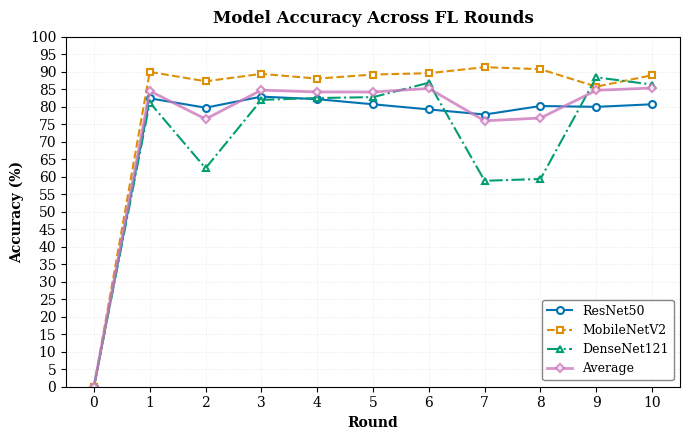


Figure 2: Confusion matrices...
  ✓ Saved: confusion_matrices.png + .pdf


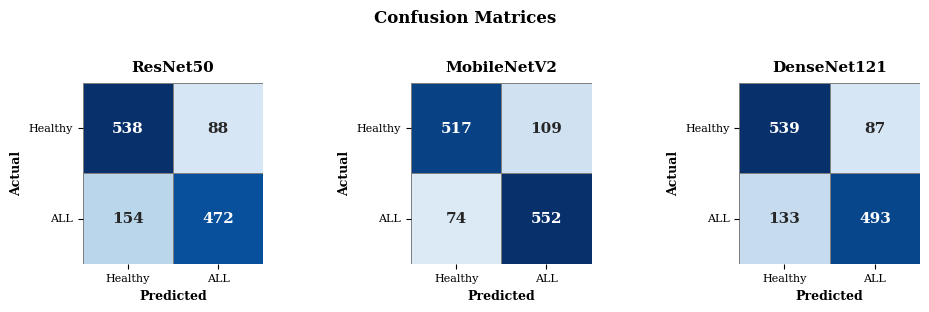


✅ COMPLETE - Ready for publication!


In [ ]:
# ==========================================
# PUBLICATION-READY FL METRICS VISUALIZATION
# Conference Paper Quality - Minimal Design
# WITH ZOOMED ACCURACY PLOT
# ==========================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from supabase import create_client, Client

# ==========================================
# CONFIGURATION
# ==========================================

SUPABASE_URL = os.getenv("SUPABASE_URL", "YOUR_SUPABASE_URL_HERE")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "YOUR_SUPABASE_ANON_KEY_HERE")
SIMULATION_ID = None  # None = latest

# Map client IDs to model names
CLIENT_MODEL_MAPPING = {
    1: 'ResNet50',
    2: 'MobileNetV2',
    3: 'DenseNet121'
}

# Publication-ready styling
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 0.8

# ==========================================
# DATA FETCHING
# ==========================================

def fetch_metrics(supabase, simulation_id=None):
    """Fetch and parse metrics with proper model naming."""

    # Get latest simulation
    if simulation_id is None:
        response = supabase.table('fl_simulations').select('id').order('created_at', desc=True).limit(1).execute()
        if not response.data:
            raise ValueError("❌ No simulations found")
        simulation_id = response.data[0]['id']
        print(f"📊 Using simulation ID: {simulation_id}")

    # Fetch client metrics
    response = supabase.table('client_simulation_metrics') \
        .select('*') \
        .eq('simulation_id', simulation_id) \
        .execute()

    if not response.data:
        raise ValueError(f"❌ No metrics found for simulation_id={simulation_id}")

    print(f"✅ Fetched {len(response.data)} client(s)\n")

    # Parse data
    models_data = {}

    for record in response.data:
        client_id = record['client_id']
        model_name = CLIENT_MODEL_MAPPING.get(client_id, f"Client_{client_id}")

        print(f"Processing: Client {client_id} → {model_name}")

        # Parse metrics JSON
        metrics = json.loads(record['metrics']) if isinstance(record['metrics'], str) else record['metrics']

        # ==========================================
        # EXTRACT ACCURACY PER ROUND
        # ==========================================

        rounds = []
        accuracies = []

        # Round 0: Pre-FL baseline
        pre_fl = metrics.get('global', {}).get('pre_fl', {})
        rounds.append(0)
        accuracies.append(pre_fl.get('accuracy', 0) * 100)
        print(f"  Round 0 (Pre-FL): {accuracies[0]:.2f}%")

        # Rounds 1+: FL training
        for round_entry in metrics.get('rounds', []):
            r = round_entry['round']
            val = round_entry.get('validation', {})
            acc = val.get('accuracy', 0) * 100

            rounds.append(r)
            accuracies.append(acc)
            print(f"  Round {r}: {acc:.2f}%")

        # ==========================================
        # EXTRACT CONFUSION MATRIX
        # ==========================================

        # Try post_fl first (most accurate)
        post_fl = metrics.get('global', {}).get('post_fl', {})
        cm_dict = post_fl.get('confusion_matrix', {})

        # If not found, try last round
        if not cm_dict and len(metrics.get('rounds', [])) > 0:
            last_round = metrics['rounds'][-1]
            cm_dict = last_round.get('validation', {}).get('confusion_matrix', {})

        # Build confusion matrix
        # Format: [[TN, FP],
        #          [FN, TP]]
        tn = cm_dict.get('TN', 0)
        fp = cm_dict.get('FP', 0)
        fn = cm_dict.get('FN', 0)
        tp = cm_dict.get('TP', 0)

        confusion_matrix = np.array([
            [tn, fp],
            [fn, tp]
        ])

        print(f"  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

        models_data[model_name] = {
            'client_id': client_id,
            'rounds': rounds,
            'accuracies': accuracies,
            'confusion_matrix': confusion_matrix,
            'final_accuracy': accuracies[-1]
        }

    print()
    return models_data

# ==========================================
# FIGURE 1: ACCURACY LINE GRAPH (ZOOMED)
# ==========================================

def create_accuracy_plot(models_data):
    """Publication-quality accuracy comparison with zoomed y-axis."""

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Colorblind-friendly palette
    colors = {
        'ResNet50': '#0173B2',      # Blue
        'MobileNetV2': '#DE8F05',   # Orange
        'DenseNet121': '#029E73',   # Green
        'Average': '#CC78BC'        # Purple
    }

    linestyles = {
        'ResNet50': '-',
        'MobileNetV2': '--',
        'DenseNet121': '-.',
        'Average': '-'
    }

    markers = {
        'ResNet50': 'o',
        'MobileNetV2': 's',
        'DenseNet121': '^',
        'Average': 'D'
    }

    # Plot models in order
    all_accuracies = []
    max_rounds = 0

    for model in ['ResNet50', 'MobileNetV2', 'DenseNet121']:
        if model not in models_data:
            continue

        data = models_data[model]
        rounds = data['rounds']
        accs = data['accuracies']

        ax.plot(rounds, accs,
                label=model,
                color=colors[model],
                linestyle=linestyles[model],
                marker=markers[model],
                markersize=5,
                linewidth=1.5,
                markerfacecolor='white',
                markeredgewidth=1.5)

        all_accuracies.append(accs)
        max_rounds = max(max_rounds, max(rounds))

    # Add average line
    if all_accuracies:
        min_len = min(len(a) for a in all_accuracies)
        avg = np.mean([a[:min_len] for a in all_accuracies], axis=0)

        ax.plot(range(len(avg)), avg,
                label='Average',
                color=colors['Average'],
                linestyle=linestyles['Average'],
                marker=markers['Average'],
                markersize=4,
                linewidth=2,
                markerfacecolor='white',
                markeredgewidth=1.5,
                alpha=0.8)

        all_accuracies.append(list(avg))

    # ==========================================
    # SMART Y-AXIS SCALING TO SHOW FLUCTUATIONS
    # ==========================================

    # Collect all accuracy values
    all_values = [val for accs in all_accuracies for val in accs]

    if all_values:
        min_acc = min(all_values)
        max_acc = max(all_values)
        range_acc = max_acc - min_acc

        # Add padding to show fluctuations clearly
        # If range is small, add fixed padding
        if range_acc < 10:
            padding = 5  # Add 5% padding on each side
        else:
            padding = range_acc * 0.25  # Add 25% padding

        # Set y-limits with padding, but keep within [0, 100]
        y_min = max(0, min_acc - padding)
        y_max = min(100, max_acc + padding)

        # Round to nearest 5 for cleaner axis
        y_min = np.floor(y_min / 5) * 5
        y_max = np.ceil(y_max / 5) * 5

        ax.set_ylim(y_min, y_max)

        print(f"\nY-axis range: {y_min:.1f}% to {y_max:.1f}%")
        print(f"Data range: {min_acc:.2f}% to {max_acc:.2f}%")
        print(f"Fluctuation range: {range_acc:.2f}%")

    # Style
    ax.set_xlabel('Round', fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontweight='bold')
    ax.set_title('Model Accuracy Across FL Rounds', fontweight='bold', pad=10)
    ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.5)
    ax.legend(frameon=True, loc='lower right', fontsize=9,
              framealpha=0.95, edgecolor='gray')
    ax.set_xticks(range(0, max_rounds + 1))

    # More granular y-ticks to show detail
    y_ticks = np.arange(y_min, y_max + 1, 5)
    ax.set_yticks(y_ticks)

    plt.tight_layout()
    return fig

# ==========================================
# FIGURE 2: CONFUSION MATRICES
# ==========================================

def create_confusion_plot(models_data):
    """Publication-quality confusion matrices."""

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    for idx, model in enumerate(['ResNet50', 'MobileNetV2', 'DenseNet121']):
        if model not in models_data:
            axes[idx].text(0.5, 0.5, f'{model}\nNo Data',
                          ha='center', va='center', fontsize=12)
            axes[idx].axis('off')
            continue

        ax = axes[idx]
        cm = models_data[model]['confusion_matrix']

        # Heatmap
        sns.heatmap(cm, annot=True, fmt='d',
                   cmap='Blues',
                   ax=ax,
                   cbar=False,
                   square=True,
                   linewidths=0.5,
                   linecolor='gray',
                   annot_kws={'size': 11, 'weight': 'bold'},
                   vmin=0)

        # Labels
        ax.set_title(model, fontweight='bold', pad=8, fontsize=11)
        ax.set_xlabel('Predicted', fontweight='bold', fontsize=9)
        ax.set_ylabel('Actual', fontweight='bold', fontsize=9)
        ax.set_xticklabels(['Healthy', 'ALL'], fontsize=8)
        ax.set_yticklabels(['Healthy', 'ALL'], fontsize=8, rotation=0)

    plt.suptitle('Confusion Matrices', fontweight='bold', fontsize=12, y=1.02)
    plt.tight_layout()
    return fig

# ==========================================
# MAIN EXECUTION
# ==========================================

print("="*70)
print("FL METRICS VISUALIZATION - CONFERENCE PAPER EDITION")
print("="*70)
print("\nClient → Model Mapping:")
for cid, name in CLIENT_MODEL_MAPPING.items():
    print(f"  Client {cid} = {name}")
print("\n" + "="*70)

# Fetch data
print("\n📥 FETCHING DATA FROM DATABASE\n")
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
models_data = fetch_metrics(supabase, SIMULATION_ID)

# Summary
print("="*70)
print(f"📊 SUMMARY: {len(models_data)} models loaded")
for name, data in sorted(models_data.items()):
    print(f"  • {name}: {len(data['rounds'])} rounds, final={data['final_accuracy']:.2f}%")
print("="*70)

# Generate plots
print("\n🎨 GENERATING FIGURES\n")

print("Figure 1: Accuracy comparison (ZOOMED)...")
fig1 = create_accuracy_plot(models_data)
fig1.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
fig1.savefig('accuracy_comparison.pdf', bbox_inches='tight')
print("  ✓ Saved: accuracy_comparison.png + .pdf")
plt.show()

print("\nFigure 2: Confusion matrices...")
fig2 = create_confusion_plot(models_data)
fig2.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
fig2.savefig('confusion_matrices.pdf', bbox_inches='tight')
print("  ✓ Saved: confusion_matrices.png + .pdf")
plt.show()

print("\n" + "="*70)
print("✅ COMPLETE - Ready for publication!")
print("="*70)

In [ ]:
# ==========================================
# DIAGNOSTIC: CHECK BASELINE ACCURACY VALUES
# ==========================================

import os
import json
from supabase import create_client

SUPABASE_URL = os.getenv("SUPABASE_URL", "YOUR_SUPABASE_URL_HERE")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "YOUR_SUPABASE_ANON_KEY_HERE")

print("="*70)
print("DIAGNOSTIC: CHECKING PRE-FL BASELINE ACCURACY")
print("="*70)

# Connect
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# Get latest simulation
response = supabase.table('fl_simulations').select('id').order('created_at', desc=True).limit(1).execute()
sim_id = response.data[0]['id']

print(f"\nSimulation ID: {sim_id}\n")

# Fetch metrics
response = supabase.table('client_simulation_metrics').select('*').eq('simulation_id', sim_id).execute()

CLIENT_MODEL_MAPPING = {1: 'ResNet50', 2: 'MobileNetV2', 3: 'DenseNet121'}

print("PRE-FL BASELINE ACCURACY (Round 0):")
print("-" * 70)

for record in response.data:
    client_id = record['client_id']
    model_name = CLIENT_MODEL_MAPPING.get(client_id, f"Client_{client_id}")

    metrics = json.loads(record['metrics']) if isinstance(record['metrics'], str) else record['metrics']

    # Get pre-FL metrics
    pre_fl = metrics.get('global', {}).get('pre_fl', {})
    pre_fl_acc = pre_fl.get('accuracy', 0)

    # Get Round 1 metrics (first training round)
    round_1_acc = 0
    if metrics.get('rounds') and len(metrics['rounds']) > 0:
        round_1_acc = metrics['rounds'][0].get('validation', {}).get('accuracy', 0)

    # Get final round
    final_acc = 0
    if metrics.get('rounds') and len(metrics['rounds']) > 0:
        final_acc = metrics['rounds'][-1].get('validation', {}).get('accuracy', 0)

    print(f"\n{model_name} (Client {client_id}):")
    print(f"  Pre-FL (Round 0):  {pre_fl_acc:.4f} ({pre_fl_acc*100:.2f}%)")
    print(f"  Round 1:           {round_1_acc:.4f} ({round_1_acc*100:.2f}%)")
    print(f"  Final Round:       {final_acc:.4f} ({final_acc*100:.2f}%)")
    print(f"  Improvement:       {(final_acc - pre_fl_acc)*100:.2f}%")

    # Analysis
    if pre_fl_acc < 0.01:
        print(f"  ⚠️  WARNING: Pre-FL accuracy is {pre_fl_acc*100:.2f}% - might be missing!")
    elif 0.45 <= pre_fl_acc <= 0.55:
        print(f"  ✓  This is ~50% (random baseline - untrained model)")
    elif pre_fl_acc > 0.70:
        print(f"  ✓  This is >{pre_fl_acc*100:.0f}% (likely using pretrained weights)")

    # Check all rounds
    print(f"\n  All rounds:")
    print(f"    Round 0 (Pre-FL): {pre_fl_acc*100:.2f}%")
    for i, round_data in enumerate(metrics.get('rounds', [])):
        r = round_data['round']
        acc = round_data.get('validation', {}).get('accuracy', 0) * 100
        print(f"    Round {r}: {acc:.2f}%")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("""
If Pre-FL ≈ 50%:  ✓ Correct - models start from random initialization
If Pre-FL > 70%:  ✓ Also correct - using pretrained weights (transfer learning)
If Pre-FL ≈ 0%:   ❌ Error - pre-FL baseline not recorded properly

The graph should show:
- Round 0 = Pre-FL baseline (whatever it actually is)
- Rounds 1+ = Improvement from federated learning
""")

DIAGNOSTIC: CHECKING PRE-FL BASELINE ACCURACY

Simulation ID: 1

PRE-FL BASELINE ACCURACY (Round 0):
----------------------------------------------------------------------

MobileNetV2 (Client 2):
  Pre-FL (Round 0):  0.0000 (0.00%)
  Round 1:           0.9000 (90.00%)
  Final Round:       0.8904 (89.04%)
  Improvement:       89.04%
  ⚠️  WARNING: Pre-FL accuracy is 0.00% - might be missing!

  All rounds:
    Round 0 (Pre-FL): 0.00%
    Round 1: 90.00%
    Round 2: 87.31%
    Round 3: 89.42%
    Round 4: 88.08%
    Round 5: 89.23%
    Round 6: 89.62%
    Round 7: 91.35%
    Round 8: 90.77%
    Round 9: 85.77%
    Round 10: 89.04%

ResNet50 (Client 1):
  Pre-FL (Round 0):  0.0000 (0.00%)
  Round 1:           0.8244 (82.44%)
  Final Round:       0.8073 (80.73%)
  Improvement:       80.73%
  ⚠️  WARNING: Pre-FL accuracy is 0.00% - might be missing!

  All rounds:
    Round 0 (Pre-FL): 0.00%
    Round 1: 82.44%
    Round 2: 79.76%
    Round 3: 82.93%
    Round 4: 82.20%
    Round 5: 80.73